C:\Users\HP\AppData\Local\Temp\ipykernel_19008\3868360186.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_pay, y='required_skills', x='annual_salary_usd',


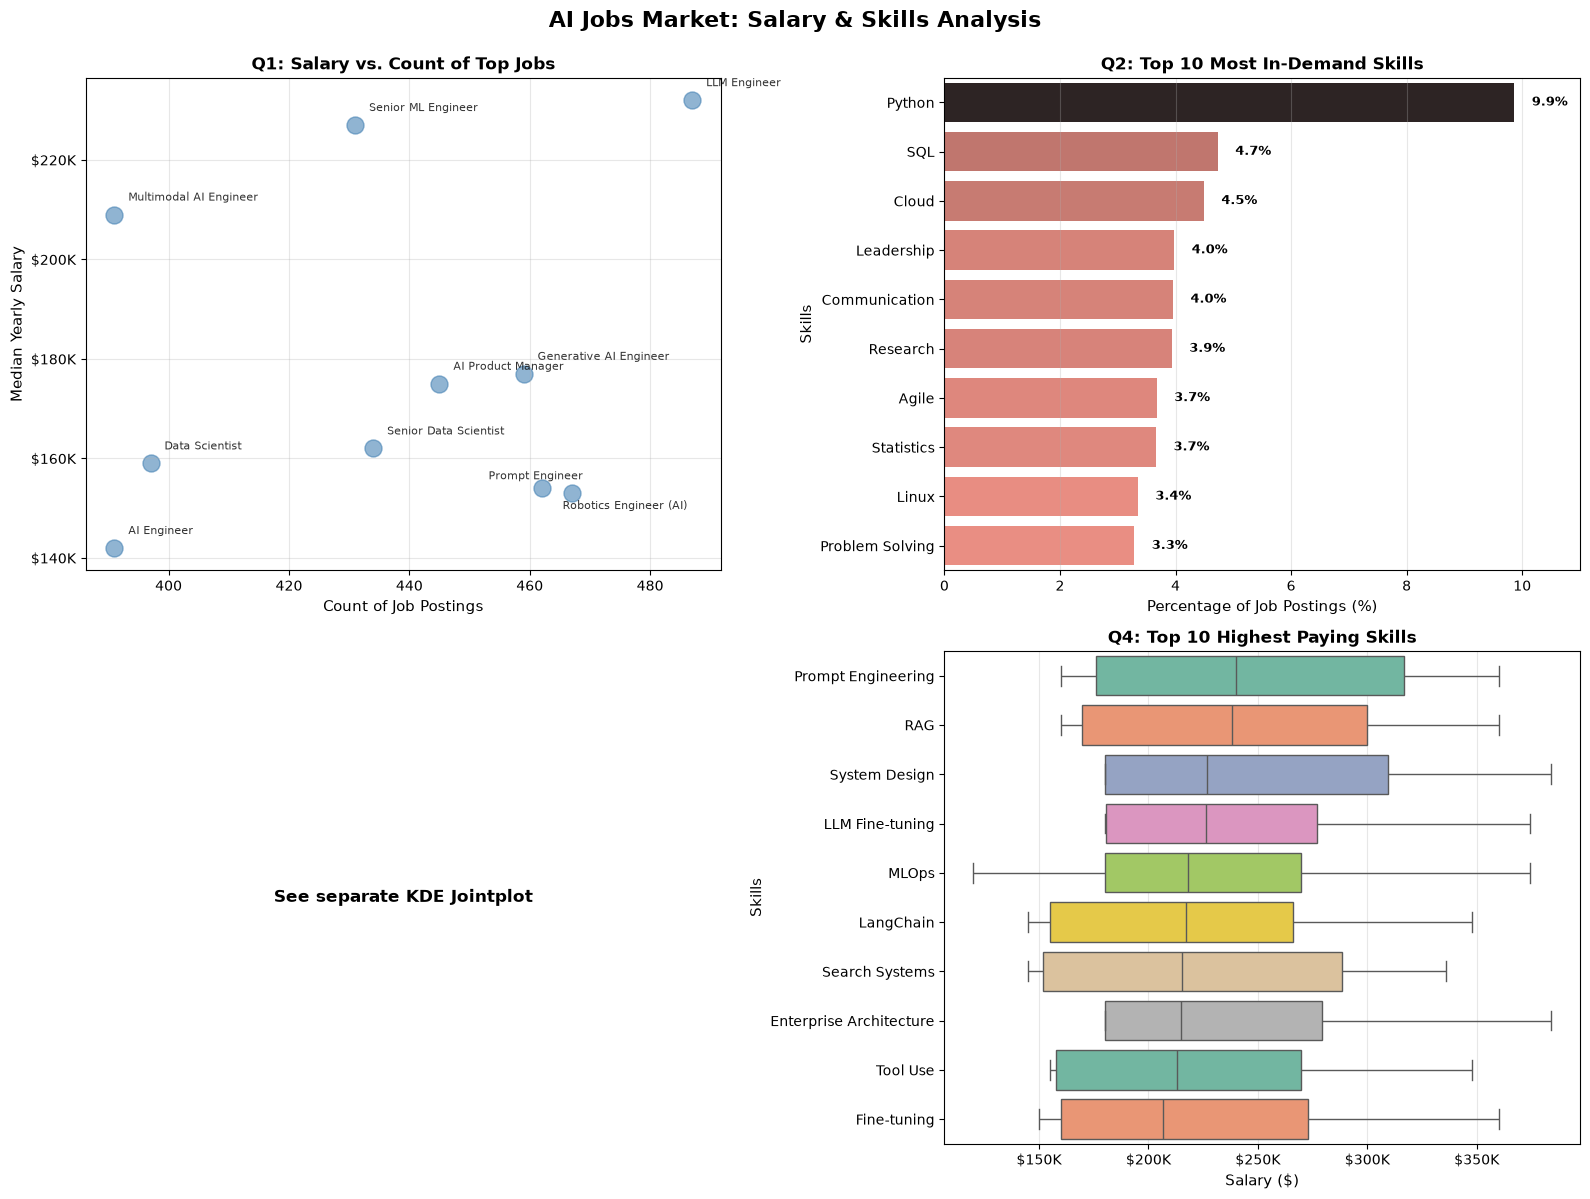

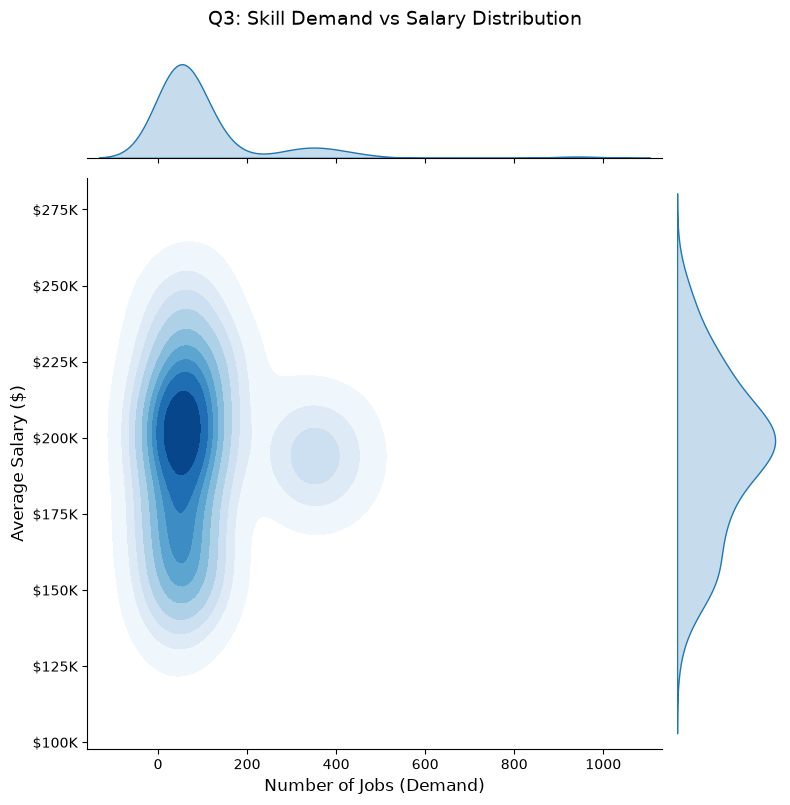

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("ai_jobs_market_2025_2026.csv")

# Data Cleanup
df['posting_year'] = pd.to_datetime(df['posting_year'])
df['posting_month'] = pd.to_datetime(df['posting_month'])
df['required_skills'] = df['required_skills'].str.split('|')
df_exploded = df.explode('required_skills')

# Calculate totals
total_jobs = len(df_exploded)

# Create 2x2 subplot for Plots 1, 2, 4
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# ===== PLOT 1 (Top-Left): Scatter - Job Title Salary vs Count =====
skill_stats = df_exploded.groupby('job_title').agg(
    median_salary=('annual_salary_usd', 'median'),
    job_count=('job_title', 'count')
)
skill_stats = skill_stats.sort_values(by='job_count', ascending=False).head(10)

ax[0, 0].scatter(skill_stats['job_count'], skill_stats['median_salary'], s=150, alpha=0.6, color='steelblue')

for idx, row in skill_stats.iterrows():
    if idx == 'Robotics Engineer (AI)':
        xytext = (15, -15)
    elif idx == 'Prompt Engineer':
        xytext = (-60, 10)
    else:
        xytext = (10, 10)
    
    ax[0, 0].annotate(idx,
                xy=(row['job_count'], row['median_salary']),
                xytext=xytext,
                textcoords='offset points',
                fontsize=8,
                alpha=0.8)

ax[0, 0].set_xlabel('Count of Job Postings', fontsize=11)
ax[0, 0].set_ylabel('Median Yearly Salary', fontsize=11)
ax[0, 0].set_title('Q1: Salary vs. Count of Top Jobs', fontsize=12, fontweight='bold')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

# ===== PLOT 2 (Top-Right): Bar - Top 10 In-Demand Skills =====
skill_counts = df_exploded['required_skills'].value_counts().head(10)
df_plot = pd.DataFrame({
    'job_skills': skill_counts.index,
    'skill_count': skill_counts.values,
})
df_plot['skill_percent'] = (df_plot['skill_count'] / total_jobs * 100)

sns.barplot(data=df_plot, y='job_skills', x='skill_percent', hue='skill_count', palette='dark:salmon_r', ax=ax[0, 1])
ax[0, 1].get_legend().remove()  # Remove the legend

for i, v in enumerate(df_plot['skill_percent']):
    ax[0, 1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

ax[0, 1].set_xlabel('Percentage of Job Postings (%)', fontsize=11)
ax[0, 1].set_ylabel('Skills', fontsize=11)
ax[0, 1].set_title('Q2: Top 10 Most In-Demand Skills', fontsize=12, fontweight='bold')
ax[0, 1].grid(True, alpha=0.3, axis='x')
ax[0, 1].set_xlim(0, 11)


# ===== PLOT 3 (Bottom-Left): REMOVED - Will be separate jointplot =====
ax[1, 0].text(0.5, 0.5, 'See separate KDE Jointplot', 
              ha='center', va='center', fontsize=12, fontweight='bold',
              transform=ax[1, 0].transAxes)
ax[1, 0].axis('off')

# ===== PLOT 4 (Bottom-Right): Boxplot - Top Paying Skills =====
top_10_skills = df_exploded.groupby('required_skills')['annual_salary_usd'].mean().nlargest(10).index
df_top_pay = df_exploded[df_exploded['required_skills'].isin(top_10_skills)]
skill_order = df_top_pay.groupby('required_skills')['annual_salary_usd'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top_pay, y='required_skills', x='annual_salary_usd', 
            order=skill_order, palette='Set2', ax=ax[1, 1],
            fliersize=6,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=8))

ax[1, 1].set_xlabel('Salary ($)', fontsize=11)
ax[1, 1].set_ylabel('Skills', fontsize=11)
ax[1, 1].set_title('Q4: Top 10 Highest Paying Skills', fontsize=12, fontweight='bold')
ax[1, 1].grid(True, alpha=0.3, axis='x')
ax[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

# Overall formatting
fig.suptitle('AI Jobs Market: Salary & Skills Analysis', fontsize=16, fontweight='bold', y=0.995)
fig.tight_layout()
plt.show()

# ===== PLOT 3 (Separate): KDE Jointplot =====
skill_stats = df_exploded.groupby('required_skills').agg(
    skill_count=('required_skills', 'count'),
    mean_salary=('annual_salary_usd', 'mean')
).reset_index()

g = sns.jointplot(data=skill_stats, x='skill_count', y='mean_salary', 
                 kind='kde', height=8, cmap='Blues', fill=True)
g.fig.suptitle('Q3: Skill Demand vs Salary Distribution', fontsize=14, y=1.00)
g.set_axis_labels('Number of Jobs (Demand)', 'Average Salary ($)', fontsize=12)
g.ax_marg_y.axis('off')
g.ax_joint.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.tight_layout()
plt.show()